### Q1. What is the relationship between polynomial functions and kernel functions in machine learning algorithms?

Ans:

The relationship between **polynomial functions** and **kernel functions** is central to how algorithms like SVM handle **non-linear data**.

---

# 🔷 1. Basic Idea

* A **polynomial function** maps input data into a **higher-dimensional space**
* A **kernel function** computes this mapping **implicitly** (without actually transforming the data)

👉 This is called the **kernel trick**

---

# 🔷 2. Polynomial Function (Explicit Mapping)

Suppose you have 2D input:
[
x = (x_1, x_2)
]

A polynomial transformation (degree 2) creates:
[
(x_1^2, x_2^2, x_1x_2)
]

📌 Meaning:

* Converts **non-linear data → linear separable** in higher dimensions

---

# 🔷 3. Polynomial Kernel (Implicit Mapping)

Instead of computing new features manually, we use:

K(x, x') = (x^T x' + c)^d

### 📌 Where:

* (d) = degree of polynomial
* (c) = constant (controls flexibility)

---

# 🔷 4. Relationship (Core Concept)

| Polynomial Function                | Polynomial Kernel          |
| ---------------------------------- | -------------------------- |
| Explicit feature transformation    | Implicit transformation    |
| Computationally expensive          | Efficient                  |
| Creates new features manually      | Uses dot products          |
| Works in higher dimension directly | Works without computing it |

👉 **Kernel = shortcut for polynomial expansion**

---

# 🔷 5. Why This Matters in SVM

In **Support Vector Machines**:

* Linear SVM fails on curved boundaries
* Polynomial kernel allows **non-linear decision boundaries**

### 📊 Example:

* Data in a **circle shape**
* Linear line ❌ cannot separate
* Polynomial kernel ✅ separates perfectly

---

# 🔷 6. Simple Intuition

Think of it like:

* Polynomial function → **actually lifting data into 3D**
* Kernel → **pretending it’s lifted, without doing it**

---

# 🔷 7. Real-Life Analogy

* Polynomial mapping = physically building a 3D model
* Kernel trick = using a **mathematical shortcut** to get same result

---

# 🔷 Final Conclusion

👉 Polynomial functions and kernel functions are directly related because:

* **Kernel functions simulate polynomial transformations**
* They allow algorithms to handle **complex, non-linear patterns efficiently**
* This is why kernels are powerful in SVM and other ML models



### Q2. How can we implement an SVM with a polynomial kernel in Python using Scikit-learn?

Ans:

What is Polynomial Kernel in SVM?

* It allows SVM to create non-linear decision boundaries using:


K(x,x
′
)=(x
T
x
′
+c)
d

* d → degree of polynomial
* c → constant term (coef0 in sklearn)


🔷 2. Step-by-Step Implementation in Python

In [1]:
# Step 1: Import Libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Step 2: Load Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Step 4: Train SVM with Polynomial Kernel
model = SVC(
    kernel='poly',   # polynomial kernel
    degree=3,        # degree of polynomial
    coef0=1,         # constant term (c)
    C=1              # regularization
)

model.fit(X_train, y_train)

SVC(C=1, coef0=1, kernel='poly')

In [5]:
# Step 5: Prediction
y_pred = model.predict(X_test)

In [6]:
# Step 6: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


### 3. Visualizing Decision Boundary (2 Features Only)

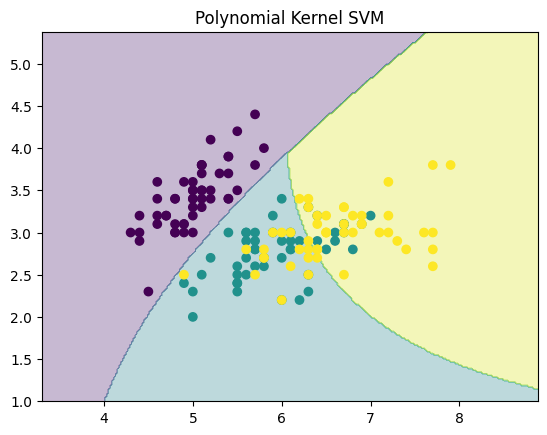

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Use only 2 features for plotting
X = iris.data[:, :2]
y = iris.target

model = SVC(kernel='poly', degree=3, coef0=1, C=1)
model.fit(X, y)

def plot_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Polynomial Kernel SVM")
    plt.show()

plot_boundary(model, X, y)

### 4. Effect of Parameters
| Parameter | Effect                                 |
| --------- | -------------------------------------- |
| degree ↑  | More complex boundary                  |
| C ↑       | Less regularization (overfitting risk) |
| coef0 ↑   | More influence of higher-order terms   |

An SVM with a polynomial kernel in Scikit-learn is implemented using SVC(kernel='poly'). The kernel computes similarity as a polynomial function, allowing the model to learn non-linear decision boundaries. Key parameters include degree, C, and coef0.

### Q3. How does increasing the value of epsilon affect the number of support vectors in SVR?

Ans:

In **Support Vector Regression (SVR)**, the parameter **ε (epsilon)** defines a **margin of tolerance** around the regression function.

---

# 🔷 1. What is ε in SVR?

It creates an **ε-insensitive tube** around the predicted function:

∣yi​−f(xi​)∣≤ϵ

👉 Points inside this tube are **not penalized**.

---

# 🔷 2. Effect of Increasing ε

### 📌 Key Idea:

👉 **As ε increases → number of support vectors decreases**

---

# 🔷 3. Why Does This Happen?

* **Small ε**:

  * Narrow tube
  * Many points fall **outside**
  * 👉 More support vectors

* **Large ε**:

  * Wide tube
  * More points fall **inside**
  * 👉 Fewer support vectors

---

# 🔷 4. Visual Intuition

### Small ε (more support vectors)

```
   •  •
  •    •   ← many outside tube
----f(x)----
```

### Large ε (fewer support vectors)

```
   •  •
  •    •   ← most inside tube
-- wide tube --
----f(x)----
```

---

# 🔷 5. Impact on Model

| ε Value | Support Vectors | Model Behavior             |
| ------- | --------------- | -------------------------- |
| Small ε | More            | Complex, fits data closely |
| Large ε | Fewer           | Simpler, smoother function |

---

# 🔷 6. Trade-off

* **Small ε** → Low bias, high variance (overfitting risk)
* **Large ε** → High bias, low variance (underfitting risk)

---


👉 *Increasing the value of ε in SVR widens the ε-insensitive region, causing more data points to fall inside the margin. As a result, fewer points act as support vectors, leading to a simpler and smoother regression model.*



### Q4. How does the choice of kernel function, C parameter, epsilon parameter, and gamma parameter affect the performance of Support Vector Regression (SVR)? Can you explain how each parameter works and provide examples of when you might want to increase or decrease its value?

Ans:



# 🔷 1. Kernel Function (Shape of the Model)

### 📌 What it does:

Transforms data to capture patterns.

### Common kernels:

* **Linear** → straight line
* **Polynomial** → curved (controlled complexity)
* **RBF (Gaussian)** → very flexible, captures complex patterns

### 📊 Effect:

| Kernel     | Behavior                   |
| ---------- | -------------------------- |
| Linear     | Simple, fast, low variance |
| Polynomial | Medium complexity          |
| RBF        | Highly flexible            |

### ✅ When to use:

* Linear → large dataset, simple trend
* Polynomial → moderate non-linearity
* RBF → complex, unknown patterns (most common)

---

# 🔷 2. C Parameter (Regularization)

### 📌 What it does:

Controls **penalty for errors** (points outside ε-tube)

### 📊 Effect:

| C Value | Behavior                            |
| ------- | ----------------------------------- |
| Small C | Allows more errors → smoother model |
| Large C | Penalizes errors → fits closely     |

### 🎯 Intuition:

* **Low C** → ignore noise
* **High C** → try to fit every point

### ✅ When to adjust:

* Increase C → when underfitting
* Decrease C → when overfitting

---

# 🔷 3. Epsilon (ε) Parameter (Tolerance Zone)

### 📌 What it does:

Defines the **ε-insensitive tube**:

∣yi​−f(xi​)∣≤ϵ

### 📊 Effect:

| ε Value | Behavior                     |
| ------- | ---------------------------- |
| Small ε | Narrow tube → more sensitive |
| Large ε | Wide tube → less sensitive   |

### 🎯 Impact:

* Small ε → more support vectors, complex model
* Large ε → fewer support vectors, smoother model

### ✅ When to adjust:

* Increase ε → noisy data
* Decrease ε → need precise predictions

---

# 🔷 4. Gamma (γ) Parameter (for RBF/Poly)

### 📌 What it does:

Controls **influence of a single data point**

### 📊 Effect:

| Gamma  | Behavior                       |
| ------ | ------------------------------ |
| Low γ  | Far influence → smooth curve   |
| High γ | Near influence → complex curve |

### 🎯 Intuition:

* Low γ → generalized model
* High γ → focuses on nearby points

### ✅ When to adjust:

* Increase γ → capture fine patterns
* Decrease γ → avoid overfitting

---

# 🔷 5. Combined Effect (Very Important)

| Parameter | Controls        | High Value Effect | Low Value Effect |
| --------- | --------------- | ----------------- | ---------------- |
| Kernel    | Model type      | Complex boundary  | Simple boundary  |
| C         | Error penalty   | Overfit risk      | Underfit risk    |
| ε         | Tolerance       | Smooth model      | Sensitive model  |
| γ         | Local influence | Overfit risk      | Underfit risk    |

---

# 🔷 6. Practical Example

### 📊 Scenario: Noisy Data

* Use:

  * **Low C**
  * **High ε**
  * **Low γ**
    👉 Result → smoother, robust model

---

### 📊 Scenario: High Precision Required

* Use:

  * **High C**
  * **Low ε**
  * **High γ**
    👉 Result → tightly fitted model

---


👉 *The kernel defines the shape of the regression function. The parameter C controls the trade-off between smoothness and error penalty, ε defines the width of the insensitive zone, and γ controls the influence of individual data points. Proper tuning of these parameters balances underfitting and overfitting.*




### Q5. Assignment:
* Import the necessary libraries and load the dataset
* Split the dataset into training and testing sets
* Preprocess the data using any technique of your choice (e.g. scaling, normalization)
* Create an instance of the SVC classifier and train it on the training data
* Use the trained classifier to predict the labels of the testing data
* Evaluate the performance of the classifier using any metric of your choice (e.g. accuracy,
precision, recall, F1-score)
* Tune the hyperparameters of the SVC classifier using GridSearchCV or RandomizedSearchCV to
improve its performance
* Train the tuned classifier on the entire dataset
* Save the trained classifier to a file for future use.

Note:
You can use any dataset of your choice for this assignment, but make sure it is suitable for
classification and has a sufficient number of features and samples.

Ans:





In [8]:
# 1. Import Libraries & Load Dataset

# (Using Iris dataset for simplicity—you can replace it later)

import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [9]:
# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [10]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 3. Data Preprocessing (Scaling)
# Important for SVM performance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# 4. Train SVC Model
model = SVC(kernel='rbf', C=1, gamma='scale')

model.fit(X_train, y_train)

SVC(C=1)

In [13]:
# 5. Predictions
y_pred = model.predict(X_test)

In [14]:
# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
# 7. Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [16]:
# 8. Train Tuned Model
best_model = grid.best_estimator_

# Evaluate again
y_pred = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Tuned Accuracy: 0.9666666666666667


In [17]:
# 9. Train on Entire Dataset
# Scale full data
X_scaled = scaler.fit_transform(X)

# Train final model
final_model = SVC(**grid.best_params_)
final_model.fit(X_scaled, y)

SVC(C=100, gamma=0.01)

In [18]:
# 10. Save Model
joblib.dump(final_model, "svc_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [19]:
# 11. Load Model (Future Use)
loaded_model = joblib.load("svc_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Example prediction
sample = X[0].reshape(1, -1)
sample = loaded_scaler.transform(sample)

print("Prediction:", loaded_model.predict(sample))

Prediction: [0]


### 🔷 Key Points :
* Scaling is mandatory for SVM
* GridSearchCV finds optimal hyperparameters
* C, gamma, kernel are most important
* Model persistence done using joblib

🔷 Summary

This pipeline includes:

✔ Data loading

✔ Preprocessing

✔ Model training

✔ Evaluation

✔ Hyperparameter tuning

✔ Final training

✔ Model saving